# 04 — Acerto por edital e categoria

Análise do desempenho em diferentes contextos de pergunta.

In [1]:
# Configuração comum dos estudos integrados
from pathlib import Path
import re
import math
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

pd.set_option('display.max_columns', 80)
pd.set_option('display.max_colwidth', 120)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.bbox'] = 'tight'
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.22

ARTEFATOS = {
    'unificado': 'result_unificado_final.xlsx',
    'ferramenta': 'result_ferramenta_final.xlsx',
    'chats': 'result_chats_final.xlsx',
}

PASTAS_PROVAVEIS = [
    Path('../artefatos'),
    Path('../../artefatos'),
    Path('artefatos'),
    Path('../'),
    Path('.'),
    Path('/mnt/data'),
]

def encontra_arquivo(nome):
    for pasta in PASTAS_PROVAVEIS:
        caminho = pasta / nome
        if caminho.exists():
            return caminho.resolve()
    raise FileNotFoundError(
        f'Arquivo não encontrado: {nome}. Coloque os artefatos em ../artefatos/, artefatos/ ou na mesma pasta do notebook.'
    )

NOMES_MODELOS = {
    'claude-haiku-4-5': 'Claude Haiku',
    'claude-opus-4-7': 'Claude Opus',
    'claude-sonnet-4-6': 'Claude Sonnet',
    'deepseek-v4-flash': 'DeepSeek Flash',
    'deepseek-v4-pro': 'DeepSeek Pro',
    'gpt-4o-mini': 'GPT 4o mini',
    'gpt-5.4': 'GPT 5.4',
    'gpt-5.4-mini': 'GPT 5.4 mini',
    'gpt-5.5': 'GPT 5.5',
    'std_chatgpt': 'ChatGPT comercial',
    'std_claude': 'Claude comercial',
}

def provedor(modelo):
    m = str(modelo).lower()
    if 'claude' in m:
        return 'Anthropic'
    if 'gpt' in m or 'chatgpt' in m:
        return 'OpenAI'
    if 'deepseek' in m:
        return 'DeepSeek'
    return 'Outro'

def prepara(df, origem_padrao=None):
    """Cria campos de leitura do TCC em memória. Não salva nenhuma base intermediária."""
    df = df.copy()
    if 'origem_resultado' not in df.columns:
        df['origem_resultado'] = origem_padrao or 'nao_informada'
    for col in [
        'avaliacao_final', 'concisao_score', 'avaliacao_gpt', 'avaliacao_opus',
        'avaliacao_humana', 'resposta_tokens_tiktoken', 'input_tokens', 'output_tokens',
        'custo_estimado_usd', 'n_invocacoes', 'latencia_s'
    ]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col].replace('nao pertinente', np.nan), errors='coerce')
    if 'convergencia' in df.columns:
        df['convergencia'] = df['convergencia'].astype(bool)
    else:
        df['convergencia'] = np.nan
    df['acerto'] = df['avaliacao_final']
    df['resposta_direta'] = df['concisao_score']
    df['discordancia_avaliadores'] = ~df['convergencia']
    df['origem_legivel'] = df['origem_resultado'].map({
        'ferramenta': 'Ferramenta',
        'chat_comercial': 'Chat comercial'
    }).fillna(df['origem_resultado'])
    df['modelo_legivel'] = df['modelo'].map(NOMES_MODELOS).fillna(df['modelo'])
    df['provedor'] = df['modelo'].map(provedor)
    df['status_acerto'] = pd.cut(
        df['acerto'], bins=[-0.01, 0.01, 0.99, 1.01],
        labels=['Incorreta', 'Parcial', 'Correta']
    )
    df['acerto_total'] = (df['acerto'] == 1).astype(int)
    df['erro_total'] = (df['acerto'] == 0).astype(int)
    df['parcial'] = (df['acerto'] == 0.5).astype(int)
    df['nao_totalmente_correta'] = (df['acerto'] < 1).astype(int)
    return df

def ler_artefatos():
    caminhos = {k: encontra_arquivo(v) for k, v in ARTEFATOS.items()}
    df_unificado = prepara(pd.read_excel(caminhos['unificado']))
    df_ferramenta = prepara(pd.read_excel(caminhos['ferramenta']), 'ferramenta')
    df_chats = prepara(pd.read_excel(caminhos['chats']), 'chat_comercial')
    return caminhos, df_unificado, df_ferramenta, df_chats

caminhos, df, df_ferramenta, df_chats = ler_artefatos()
print('Artefatos lidos:')
for nome, caminho in caminhos.items():
    print(f'- {nome}: {caminho}')
print(f'Base unificada: {df.shape[0]} linhas x {df.shape[1]} colunas')

# Ordem padrão dos modelos: maior acerto médio primeiro.
ORDEM_MODELOS = (
    df.groupby('modelo_legivel')['acerto']
      .mean()
      .sort_values(ascending=False)
      .index
      .tolist()
)

def pct(x):
    if pd.isna(x):
        return ''
    return f'{100*x:.1f}%'

def dinheiro(x):
    if pd.isna(x):
        return ''
    return f'US$ {x:.5f}'

def resumo_metricas(data, grupo):
    g = data.groupby(grupo, observed=True)
    out = g.agg(
        n=('acerto', 'size'),
        acerto_medio=('acerto', 'mean'),
        taxa_correta=('acerto_total', 'mean'),
        taxa_parcial=('parcial', 'mean'),
        taxa_incorreta=('erro_total', 'mean'),
        resposta_direta=('resposta_direta', 'mean'),
        discordancia=('discordancia_avaliadores', 'mean'),
        tokens_resposta=('resposta_tokens_tiktoken', 'mean'),
    ).reset_index()
    return out

def ordena_por_modelo(series_or_df, col=None):
    if isinstance(series_or_df, pd.Series):
        return series_or_df.reindex([m for m in ORDEM_MODELOS if m in series_or_df.index])
    return series_or_df.set_index(col).reindex([m for m in ORDEM_MODELOS if m in series_or_df[col].values]).reset_index()

def barh_series(s, titulo, xlabel='', percentual=False, figsize=(8, 5), limite=None):
    s = s.dropna().copy()
    if limite is not None:
        s = s.sort_values(ascending=False).head(limite)
    else:
        s = s.sort_values(ascending=True)
    vals = s * 100 if percentual else s
    fig, ax = plt.subplots(figsize=figsize)
    ax.barh(vals.index.astype(str), vals.values)
    ax.set_title(titulo, loc='left')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('')
    ax.grid(axis='y', visible=False)
    plt.tight_layout()
    plt.show()

def bar_series(s, titulo, xlabel='', ylabel='', percentual=False, figsize=(8, 4), rot=0):
    s = s.dropna().copy()
    vals = s * 100 if percentual else s
    fig, ax = plt.subplots(figsize=figsize)
    ax.bar(vals.index.astype(str), vals.values)
    ax.set_title(titulo, loc='left')
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.tick_params(axis='x', rotation=rot)
    ax.grid(axis='x', visible=False)
    plt.tight_layout()
    plt.show()

def stacked_percent(data, index_col, column_col, titulo, ordem_colunas=None, figsize=(9, 6)):
    tab = pd.crosstab(data[index_col], data[column_col], normalize='index')
    if ordem_colunas:
        tab = tab.reindex(columns=[c for c in ordem_colunas if c in tab.columns])
    tab = tab.loc[tab.sum(axis=1).sort_values().index]
    ax = (tab * 100).plot(kind='barh', stacked=True, figsize=figsize)
    ax.set_title(titulo, loc='left')
    ax.set_xlabel('% das respostas')
    ax.set_ylabel('')
    ax.legend(title='', bbox_to_anchor=(1.02, 1), loc='upper left')
    ax.grid(axis='y', visible=False)
    plt.tight_layout()
    plt.show()
    return tab

def heatmap_tabela(pivot, titulo, formato='.1f', percentual=True, figsize=(9, 5)):
    dados = pivot.copy()
    valores = dados.values * 100 if percentual else dados.values
    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(valores, aspect='auto')
    ax.set_title(titulo, loc='left')
    ax.set_xticks(np.arange(dados.shape[1]))
    ax.set_xticklabels(dados.columns.astype(str), rotation=35, ha='right')
    ax.set_yticks(np.arange(dados.shape[0]))
    ax.set_yticklabels(dados.index.astype(str))
    # Só anota quando a matriz é pequena o suficiente para não virar poluição visual.
    if dados.shape[0] * dados.shape[1] <= 80:
        for i in range(dados.shape[0]):
            for j in range(dados.shape[1]):
                val = valores[i, j]
                if not np.isnan(val):
                    texto = f'{val:{formato}}' + ('%' if percentual else '')
                    ax.text(j, i, texto, ha='center', va='center', fontsize=8)
    fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
    plt.tight_layout()
    plt.show()

def boxplot_por_grupo(data, valor, grupo, titulo, ylabel='', figsize=(9, 5), ordem=None):
    base = data[[valor, grupo]].dropna()
    if ordem is None:
        ordem = base.groupby(grupo)[valor].median().sort_values().index.tolist()
    grupos = [base.loc[base[grupo] == g, valor].values for g in ordem if g in base[grupo].unique()]
    labels = [g for g in ordem if g in base[grupo].unique()]
    fig, ax = plt.subplots(figsize=figsize)
    ax.boxplot(grupos, labels=labels, vert=False, showfliers=False)
    ax.set_title(titulo, loc='left')
    ax.set_xlabel(ylabel or valor)
    ax.set_ylabel('')
    plt.tight_layout()
    plt.show()

def tabela_formatada(data, percent_cols=None, money_cols=None, round_cols=None, n=20):
    out = data.copy().head(n)
    percent_cols = percent_cols or []
    money_cols = money_cols or []
    round_cols = round_cols or []
    for c in percent_cols:
        if c in out.columns:
            out[c] = out[c].map(pct)
    for c in money_cols:
        if c in out.columns:
            out[c] = out[c].map(dinheiro)
    for c in round_cols:
        if c in out.columns:
            out[c] = out[c].round(3)
    display(out)

def texto_curto(s, n=180):
    if pd.isna(s):
        return ''
    s = re.sub(r'\s+', ' ', str(s)).strip()
    return s if len(s) <= n else s[:n-1] + '…'

Artefatos lidos:
- unificado: /home/julio/Documentos/tcc_GENAI/v8/edital-assistant/eval/artefatos/result_unificado_final.xlsx
- ferramenta: /home/julio/Documentos/tcc_GENAI/v8/edital-assistant/eval/artefatos/result_ferramenta_final.xlsx
- chats: /home/julio/Documentos/tcc_GENAI/v8/edital-assistant/eval/artefatos/result_chats_final.xlsx
Base unificada: 1650 linhas x 34 colunas


## Pergunta do estudo
O desempenho muda conforme edital, categoria ou tipo de pergunta?

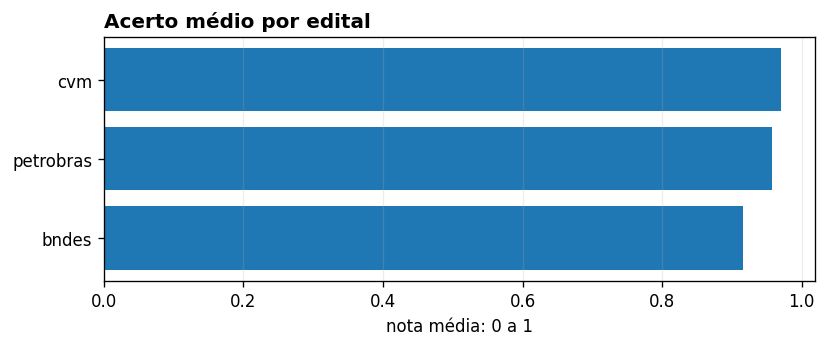

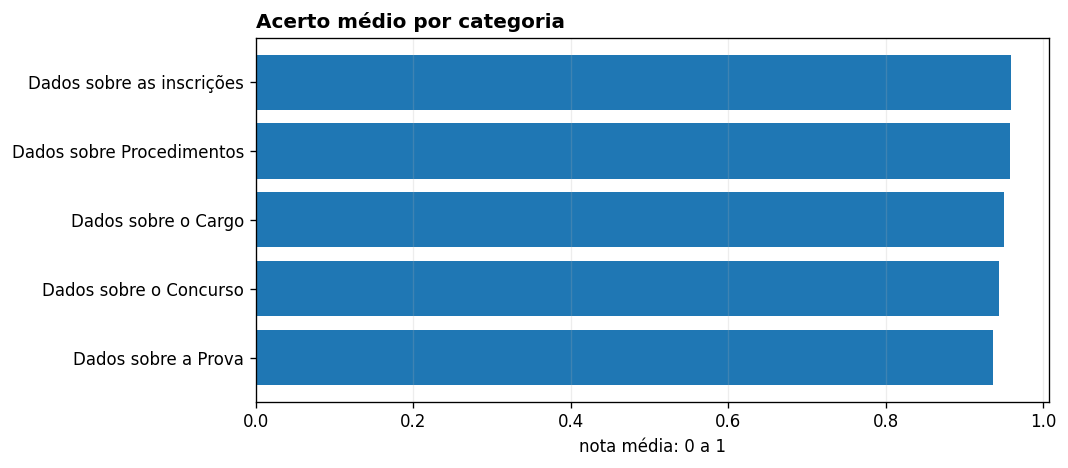

In [2]:
barh_series(df.groupby('edital')['acerto'].mean().sort_values(), 'Acerto médio por edital', 'nota média: 0 a 1', figsize=(7, 3))
barh_series(df.groupby('categoria')['acerto'].mean().sort_values(), 'Acerto médio por categoria', 'nota média: 0 a 1', figsize=(9, 4))

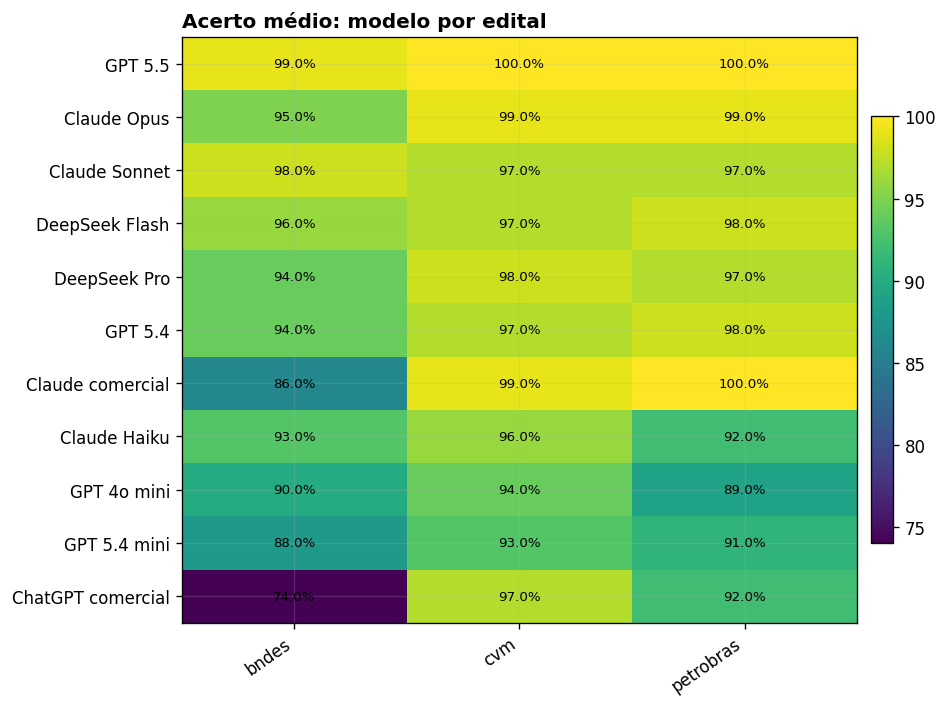

In [3]:
pivot = df.pivot_table(index='modelo_legivel', columns='edital', values='acerto', aggfunc='mean').reindex(ORDEM_MODELOS)
heatmap_tabela(pivot, 'Acerto médio: modelo por edital', formato='.1f', percentual=True, figsize=(8, 6))

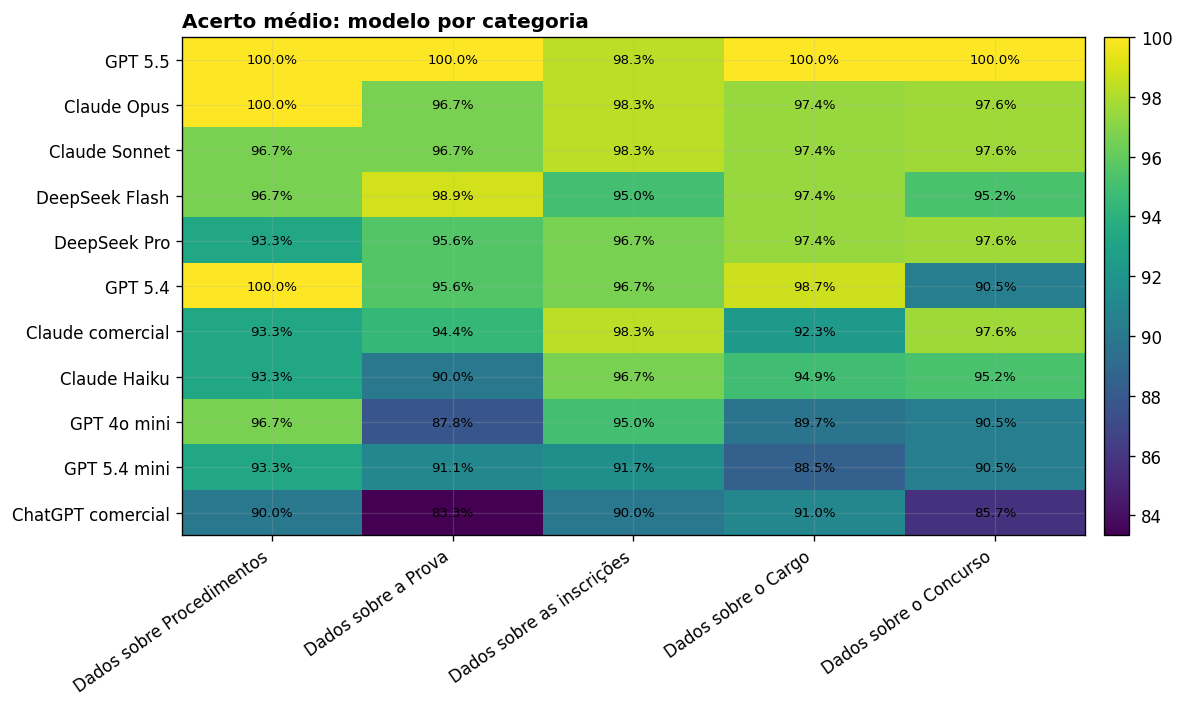

In [4]:
pivot = df.pivot_table(index='modelo_legivel', columns='categoria', values='acerto', aggfunc='mean').reindex(ORDEM_MODELOS)
heatmap_tabela(pivot, 'Acerto médio: modelo por categoria', formato='.1f', percentual=True, figsize=(10, 6))

In [5]:
# Ranking dentro de cada edital.
rankings = []
for edital, sub in df.groupby('edital'):
    r = sub.groupby('modelo_legivel')['acerto'].mean().sort_values(ascending=False).reset_index()
    r['posicao_no_edital'] = np.arange(1, len(r)+1)
    r['edital'] = edital
    rankings.append(r)
rankings = pd.concat(rankings, ignore_index=True)
display(rankings[['edital','posicao_no_edital','modelo_legivel','acerto']].sort_values(['edital','posicao_no_edital']).head(40))

,edital,posicao_no_edital,modelo_legivel,acerto
0,bndes,1,GPT 5.5,0.99
1,bndes,2,Claude Sonnet,0.98
2,bndes,3,DeepSeek Flash,0.96
3,bndes,4,Claude Opus,0.95
4,bndes,5,DeepSeek Pro,0.94
5,bndes,6,GPT 5.4,0.94
6,bndes,7,Claude Haiku,0.93
7,bndes,8,GPT 4o mini,0.90
8,bndes,9,GPT 5.4 mini,0.88
9,bndes,10,Claude comercial,0.86


In [6]:
# Categorias mais fáceis e mais difíceis pela taxa de acerto total.
cat = df.groupby('categoria').agg(
    acerto_medio=('acerto','mean'),
    taxa_correta=('acerto_total','mean'),
    taxa_incorreta=('erro_total','mean'),
    n=('acerto','size')
).sort_values('acerto_medio')
tabela_formatada(cat.reset_index(), percent_cols=['acerto_medio','taxa_correta','taxa_incorreta'], n=10)

,categoria,acerto_medio,taxa_correta,taxa_incorreta,n
0,Dados sobre a Prova,93.6%,89.1%,1.8%,495
1,Dados sobre o Concurso,94.4%,90.9%,2.2%,231
2,Dados sobre o Cargo,95.0%,90.9%,0.9%,429
3,Dados sobre Procedimentos,95.8%,92.1%,0.6%,165
4,Dados sobre as inscrições,95.9%,92.1%,0.3%,330


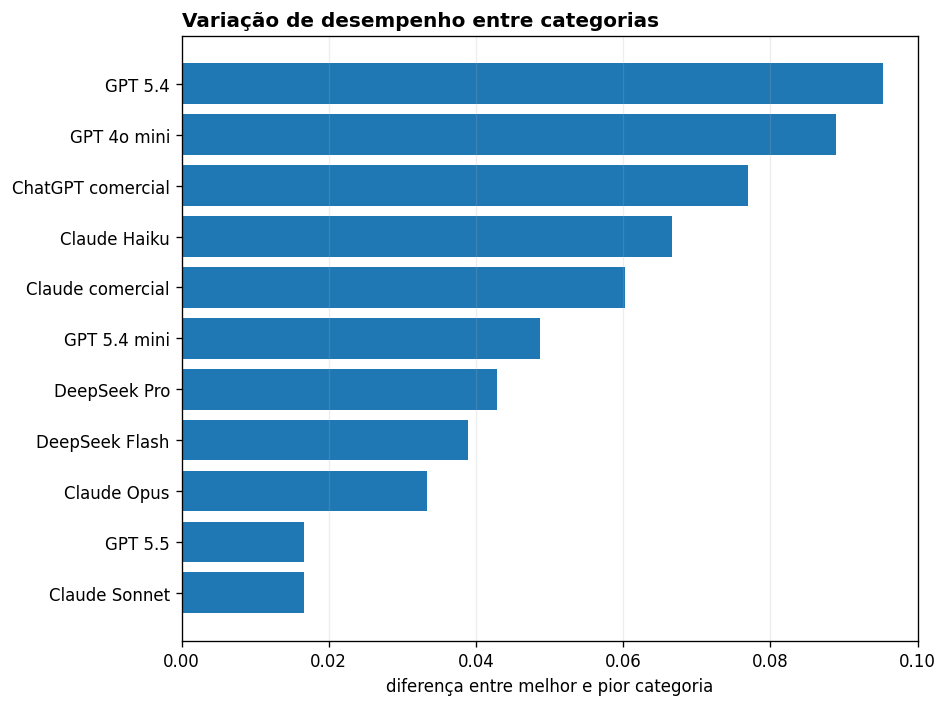

,modelo_legivel,pior_categoria,melhor_categoria,amplitude,media
0,GPT 5.4,90.5%,100.0%,9.5%,96.3%
1,GPT 4o mini,87.8%,96.7%,8.9%,91.9%
2,ChatGPT comercial,83.3%,91.0%,7.7%,88.0%
3,Claude Haiku,90.0%,96.7%,6.7%,94.0%
4,Claude comercial,92.3%,98.3%,6.0%,95.2%
5,GPT 5.4 mini,88.5%,93.3%,4.9%,91.0%
6,DeepSeek Pro,93.3%,97.6%,4.3%,96.1%
7,DeepSeek Flash,95.0%,98.9%,3.9%,96.6%
8,Claude Opus,96.7%,100.0%,3.3%,98.0%
9,GPT 5.5,98.3%,100.0%,1.7%,99.7%


In [7]:
# Estabilidade: quanto o acerto de cada modelo varia entre categorias.
var_cat = df.pivot_table(index='modelo_legivel', columns='categoria', values='acerto', aggfunc='mean')
estabilidade = pd.DataFrame({
    'pior_categoria': var_cat.min(axis=1),
    'melhor_categoria': var_cat.max(axis=1),
    'amplitude': var_cat.max(axis=1) - var_cat.min(axis=1),
    'media': var_cat.mean(axis=1)
}).sort_values('amplitude', ascending=False)
barh_series(estabilidade['amplitude'].sort_values(), 'Variação de desempenho entre categorias', 'diferença entre melhor e pior categoria', figsize=(8, 6))
tabela_formatada(estabilidade.reset_index(), percent_cols=['pior_categoria','melhor_categoria','amplitude','media'], n=20)

In [8]:
# Perguntas mais difíceis: média por edital/id/pergunta.
perguntas = df.groupby(['edital','id','categoria','pergunta']).agg(
    acerto_medio=('acerto','mean'),
    taxa_incorreta=('erro_total','mean'),
    taxa_parcial=('parcial','mean'),
    n=('acerto','size')
).sort_values(['acerto_medio','taxa_incorreta'], ascending=[True, False]).reset_index()
perguntas['pergunta_curta'] = perguntas['pergunta'].map(lambda x: texto_curto(x, 120))
display(perguntas[['edital','id','categoria','pergunta_curta','acerto_medio','taxa_incorreta','taxa_parcial','n']].head(15))

,edital,id,categoria,pergunta_curta,acerto_medio,taxa_incorreta,taxa_parcial,n
0,bndes,9,Dados sobre as inscrições,O candidato pode fazer mais de uma inscrição no concurso BNDES?,0.636364,0.000000,0.727273,11
1,bndes,37,Dados sobre a Prova,Como é dividida a prova de conhecimentos específicos de Ciência de Dados no concurso BNDES?,0.636364,0.000000,0.727273,11
2,bndes,44,Dados sobre a Prova,Quantas provas discursivas de Ciência de Dados serão corrigidas no concurso BNDES?,0.681818,0.090909,0.454545,11
3,cvm,25,Dados sobre o Cargo,Qual é a jornada de trabalho do cargo no concurso CVM?,0.681818,0.000000,0.636364,11
4,petrobras,17,Dados sobre o Concurso,Existe possibilidade de impugnar o edital do concurso PETROBRAS?,0.727273,0.181818,0.181818,11
5,bndes,10,Dados sobre as inscrições,O candidato precisa guardar o comprovante de inscrição ou pagamento do concurso BNDES?,0.727273,0.000000,0.545455,11
6,bndes,45,Dados sobre a Prova,Como é calculada a nota final do concurso BNDES para Ciência de Dados?,0.772727,0.090909,0.272727,11
7,bndes,38,Dados sobre a Prova,Qual é o critério mínimo de aprovação na prova objetiva do concurso BNDES?,0.772727,0.000000,0.454545,11
8,cvm,50,Dados sobre Procedimentos,Quais cuidados o candidato deve ter com o cartão ou folha de respostas no concurso CVM?,0.772727,0.000000,0.454545,11
9,bndes,42,Dados sobre a Prova,Quantos pontos vale a prova discursiva do concurso BNDES?,0.818182,0.181818,0.000000,11
